In [5]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path

ROOT = Path().resolve().parents[0]
sys.path.append(str(ROOT))
print(ROOT)

from database.connectie.connectie import get_engine,getData

C:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026


In [6]:
engine = get_engine()

In [7]:
query_market = """
    SELECT
        fm.DateKey,
        dd.FullDateAlternateKey   AS TradeDate,
        fm.StockKey,
        fm.[Open],
        fm.High,
        fm.Low,
        fm.[Close],
        fm.Volume
    FROM FactMarketData fm
    JOIN DimDate dd ON fm.DateKey = dd.DateKey
    ORDER BY fm.StockKey, dd.FullDateAlternateKey
"""

In [8]:
df_market = getData(engine, query_market)
df_market['TradeDate'] = pd.to_datetime(df_market['TradeDate'])


In [9]:
query_econ = """
    SELECT
        fe.DateKey,
        dd.FullDateAlternateKey AS TradeDate,
        fe.USD, fe.OIL, fe.VIX, fe.YieldSpread,
        fe.InfExpectation, fe.FinStress,
        fe.FedFundsRate, fe.FedBalanceSheet,
        fe.CPI, fe.PPI, fe.Consumer_Confidence
    FROM FactEcon fe
    JOIN DimDate dd ON fe.DateKey = dd.DateKey
    ORDER BY dd.FullDateAlternateKey
"""

In [10]:
df_econ = getData(engine, query_econ)
df_econ['TradeDate'] = pd.to_datetime(df_econ['TradeDate'])

In [11]:
query_news = """
    SELECT
        fn.DateKey,
        dd.FullDateAlternateKey AS TradeDate,
        AVG(fn.PositivityScore) AS AvgNewsSentiment,
        AVG(fn.influenceScore)  AS AvgNewsInfluence,
        COUNT(*)                AS NewsCount
    FROM FactNews fn
    JOIN DimDate dd ON fn.DateKey = dd.DateKey
    GROUP BY fn.DateKey, dd.FullDateAlternateKey
    ORDER BY dd.FullDateAlternateKey
"""

In [12]:
df_news = getData(engine, query_news)
df_news['TradeDate'] = pd.to_datetime(df_news['TradeDate'])


In [13]:
query_twitter = """
    SELECT
        dt.DateKey,
        dd.FullDateAlternateKey AS TradeDate,
        AVG(dt.PositivityScore)  AS AvgTweetSentiment,
        AVG(dt.influenceScore)   AS AvgTweetInfluence,
        COUNT(*)                 AS TweetCount
    FROM DimTwitter dt
    JOIN DimDate dd ON dt.DateKey = dd.DateKey
    GROUP BY dt.DateKey, dd.FullDateAlternateKey
    ORDER BY dd.FullDateAlternateKey
"""

In [14]:
df_twitter = getData(engine, query_twitter)
df_twitter['TradeDate'] = pd.to_datetime(df_twitter['TradeDate'])

In [15]:
from sklearn.preprocessing import RobustScaler
import joblib

In [16]:
def build_feature_matrix(df_market, df_econ, df_news, df_twitter):
    df = df_market.copy()

    # Merge econ
    df = df.merge(
        df_econ.drop(columns=['DateKey']),
        on='TradeDate', how='left'
    )
    # Merge news
    df = df.merge(
        df_news.drop(columns=['DateKey']),
        on='TradeDate', how='left'
    )
    # Merge twitter
    df = df.merge(
        df_twitter.drop(columns=['DateKey']),
        on='TradeDate', how='left'
    )

    df = df.sort_values(['StockKey', 'TradeDate']).reset_index(drop=True)
    return df

In [17]:
def add_technical_indicators(df):
    grp = df.groupby('StockKey')

    # Returns
    df['Return_1d']  = grp['Close'].pct_change(1)
    df['Return_5d']  = grp['Close'].pct_change(5)
    df['Return_10d'] = grp['Close'].pct_change(10)

    # Moving averages
    df['MA_5']  = grp['Close'].transform(lambda x: x.rolling(5).mean())
    df['MA_20'] = grp['Close'].transform(lambda x: x.rolling(20).mean())
    df['MA_50'] = grp['Close'].transform(lambda x: x.rolling(50).mean())

    # MA crossover signaal
    df['MA_cross_5_20']  = (df['MA_5']  - df['MA_20'])  / df['MA_20']
    df['MA_cross_20_50'] = (df['MA_20'] - df['MA_50'])  / df['MA_50']

    # Volatiliteit (rolling std van returns)
    df['Vol_5d']  = grp['Return_1d'].transform(lambda x: x.rolling(5).std())
    df['Vol_20d'] = grp['Return_1d'].transform(lambda x: x.rolling(20).std())

    # RSI (14 periodes)
    def calc_rsi(series, window=14):
        delta = series.diff()
        gain  = delta.clip(lower=0).rolling(window).mean()
        loss  = (-delta.clip(upper=0)).rolling(window).mean()
        rs    = gain / (loss + 1e-9)
        return 100 - (100 / (1 + rs))

    df['RSI_14'] = grp['Close'].transform(calc_rsi)

    # Bollinger Bands positie
    bb_mid = grp['Close'].transform(lambda x: x.rolling(20).mean())
    bb_std = grp['Close'].transform(lambda x: x.rolling(20).std())
    df['BB_position'] = (df['Close'] - bb_mid) / (2 * bb_std + 1e-9)

    # Volume ratio (huidig vs 20d gemiddelde)
    df['Volume_ratio'] = df['Volume'] / (
        grp['Volume'].transform(lambda x: x.rolling(20).mean()) + 1e-9
    )

    # Price range (High-Low) als % van Close
    df['DayRange_pct'] = (df['High'] - df['Low']) / (df['Close'] + 1e-9)

    return df

In [18]:
# ─────────────────────────────────────────
# 2C. Label: spike/dip definitie
#     1 = spike (grote stijging morgen)
#    -1 = dip   (grote daling morgen)
#     0 = neutraal
#
#     Drempel: |return| > 1x rolling std
#     → past zich aan per stock per periode
# ─────────────────────────────────────────
def add_labels(df, threshold_multiplier = 0.4, horizon=1):
    """
    horizon=1 → voorspel return van morgen
    threshold_multiplier → hoe 'groot' moet de beweging zijn
    """
    grp = df.groupby('StockKey')

    # Toekomstige return
    df['FutureReturn'] = grp['Close'].transform(
        lambda x: x.pct_change(horizon).shift(-horizon)
    )

    # Dynamische drempel per stock (rolling 60d std van returns)
    df['ReturnStd_60d'] = grp['Return_1d'].transform(
    lambda x: x.expanding(min_periods=20).std()  # expanding = alleen verleden
    )
    
    df['Threshold'] = threshold_multiplier * df['ReturnStd_60d']

    # Label
    conditions = [
        df['FutureReturn'] >  df['Threshold'],   # spike
        df['FutureReturn'] < -df['Threshold'],   # dip
    ]
    df['Label'] = np.select(conditions, [1, -1], default=0)

    # Binair alternatief (0/1): spike of dip vs neutraal
    df['Label_binary'] = (df['Label'] != 0).astype(int)

    return df


In [19]:
# ─────────────────────────────────────────
# 2D. Alles samenvoegen + NaN droppen
# ─────────────────────────────────────────
FEATURE_COLS = [
    # Prijs-gebaseerd
    'Return_1d', 'Return_5d', 'Return_10d',
    'MA_cross_5_20', 'MA_cross_20_50',
    'Vol_5d', 'Vol_20d',
    'RSI_14', 'BB_position', 'Volume_ratio', 'DayRange_pct',
    # Macro
    'USD', 'OIL', 'VIX', 'YieldSpread',
    'InfExpectation', 'FinStress',
    'FedFundsRate', 'CPI', 'PPI', 'Consumer_Confidence',
    # Sentiment
    'AvgNewsSentiment', 'AvgNewsInfluence', 'NewsCount',
    'AvgTweetSentiment', 'AvgTweetInfluence', 'TweetCount',
]

In [20]:
def prepare_dataset(df):
    df = df.dropna(subset=FEATURE_COLS + ['Label'])
    return df

In [21]:
# ─────────────────────────────────────────
# 2E. Scaler fitten & opslaan
#     (BELANGRIJK: scaler wordt gefit op train set only)
# ─────────────────────────────────────────
def fit_and_save_scaler(df_train, feature_cols, path='scaler.joblib'):
    scaler = RobustScaler()
    scaler.fit(df_train[feature_cols])
    joblib.dump(scaler, path)
    print(f"✅ Scaler opgeslagen: {path}")
    return scaler

In [22]:
# step3_model.py
import torch
import torch.nn as nn
from torch.utils.data import Dataset

In [23]:
# ─────────────────────────────────────────
# 3A. Sequence dataset
#     Elke sample = venster van SEQ_LEN dagen
# ─────────────────────────────────────────
class StockSequenceDataset(Dataset):
    def __init__(self, df, feature_cols, label_col, seq_len=30):
        """
        df        : gesorteerd op (StockKey, TradeDate)
        seq_len   : aantal terugkijkdagen per sample
        label_col : 'Label' (3 klassen) of 'Label_binary' (2 klassen)
        """
        self.seq_len = seq_len
        self.samples = []

        for stock, grp in df.groupby('StockKey'):
            grp = grp.sort_values('TradeDate').reset_index(drop=True)
            X = grp[feature_cols].values.astype(np.float32)
            y = grp[label_col].values.astype(np.int64)

            # Verschuif label zodat -1,0,1 → 0,1,2 voor CrossEntropy
            if label_col == 'Label':
                y = y + 1  # -1→0 (dip), 0→1 (neutraal), 1→2 (spike)

            for i in range(seq_len, len(X)):
                self.samples.append((
                    X[i - seq_len : i],   # shape: (seq_len, n_features)
                    y[i]
                ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        X, y = self.samples[idx]
        return torch.tensor(X), torch.tensor(y)


In [24]:
# ─────────────────────────────────────────
# 3B. LSTM model
# ─────────────────────────────────────────
class SpikeDipLSTM(nn.Module):
    def __init__(
        self,
        n_features,
        hidden_size=128,
        num_layers=2,
        n_classes=3,       # 3 = dip/neutraal/spike  |  2 = binary
        dropout=0.3
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 64),
            nn.Sigmoid(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)    # → logits
        )

    def forward(self, x):
        # x shape: (batch, seq_len, n_features)
        lstm_out, _ = self.lstm(x)
        last_hidden  = lstm_out[:, -1, :]   # laatste tijdstap
        logits       = self.classifier(last_hidden)
        return logits

In [25]:
# step4_train.py
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd
import joblib

In [26]:
# ─── Hyperparameters ──────────────────────
SEQ_LEN      = 30
BATCH_SIZE   = 128
EPOCHS       = 50
LR           = 1e-4
HIDDEN       = 128
LAYERS       = 2
DROPOUT      = 0.3
N_CLASSES    = 3        # 3 = dip/neutraal/spike
LABEL_COL    = 'Label'  # of 'Label_binary' voor binair
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Training op: {DEVICE}")

Training op: cpu


In [27]:
df_market.to_parquet('df_market.parquet', engine='pyarrow')
df_econ.to_parquet('df_econ.parquet',engine='pyarrow')
df_news.to_parquet('df_news.parquet',engine='pyarrow')
df_twitter.to_parquet('df_twitter.parquet',engine='pyarrow')

In [28]:
df_market = pd.read_parquet('df_market.parquet', engine='pyarrow')
df_econ = pd.read_parquet('df_econ.parquet', engine='pyarrow')
df_news = pd.read_parquet('df_news.parquet', engine='pyarrow')
df_twitter = pd.read_parquet('df_twitter.parquet', engine='pyarrow')

In [29]:
df = build_feature_matrix(df_market, df_econ, df_news, df_twitter)
df = add_technical_indicators(df)
df = add_labels(df)
df = prepare_dataset(df)

In [30]:
# ─── Train / Val / Test split (tijdsgebaseerd!) ─
# Nooit random split bij tijdreeksen
df = df.sort_values(['StockKey', 'TradeDate'])
dates = df['TradeDate'].unique()
n     = len(dates)

In [31]:
train_cutoff = dates[int(n * 0.70)]
val_cutoff   = dates[int(n * 0.85)]

In [32]:
df_train = df[df['TradeDate'] <= train_cutoff]
df_val   = df[(df['TradeDate'] > train_cutoff) & (df['TradeDate'] <= val_cutoff)]
df_test  = df[df['TradeDate'] > val_cutoff]


In [33]:
print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")


Train: 123515 | Val: 26426 | Test: 19786


In [34]:
scaler = fit_and_save_scaler(df_train, FEATURE_COLS)


✅ Scaler opgeslagen: scaler.joblib


In [35]:
df_train[FEATURE_COLS] = scaler.transform(df_train[FEATURE_COLS])
df_val[FEATURE_COLS]   = scaler.transform(df_val[FEATURE_COLS])
df_test[FEATURE_COLS]  = scaler.transform(df_test[FEATURE_COLS])


In [36]:
train_ds = StockSequenceDataset(df_train, FEATURE_COLS, LABEL_COL, SEQ_LEN)
val_ds   = StockSequenceDataset(df_val,   FEATURE_COLS, LABEL_COL, SEQ_LEN)
test_ds  = StockSequenceDataset(df_test,  FEATURE_COLS, LABEL_COL, SEQ_LEN)


In [37]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)


In [38]:
all_labels = [s[1].item() for s in train_ds]
classes    = np.unique(all_labels)
weights    = compute_class_weight('balanced', classes=classes, y=all_labels)
weights_t  = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
print(f"Class weights: {dict(zip(classes, weights.round(3)))}")


Class weights: {np.int64(0): np.float64(1.229), np.int64(1): np.float64(0.776), np.int64(2): np.float64(1.115)}


In [39]:
model     = SpikeDipLSTM(len(FEATURE_COLS), HIDDEN, LAYERS, N_CLASSES, DROPOUT).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights_t)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)

In [40]:
best_val_loss = float('inf')


In [41]:
print(df["Label"].value_counts(normalize=True))

Label
 0    0.415514
 1    0.308537
-1    0.275949
Name: proportion, dtype: float64


In [ ]:
# --- Early Stopping configuratie (voeg toe boven de training loop) ---
PATIENCE = 10          # Aantal epochs zonder verbetering voor we stoppen
ES_MIN_DELTA = 1e-4    # Minimale verbetering die telt

es_counter  = 0
best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    # --- Train ---
    model.train()
    train_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item() * len(y_batch)
        preds       = logits.argmax(dim=1)
        correct    += (preds == y_batch).sum().item()
        total      += len(y_batch)

    train_loss /= total
    train_acc   = correct / total

    # --- Validatie ---
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits    = model(X_batch)
            loss      = criterion(logits, y_batch)
            val_loss += loss.item() * len(y_batch)
            preds     = logits.argmax(dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total   += len(y_batch)

    val_loss /= val_total
    val_acc   = val_correct / val_total

    scheduler.step(val_loss)

    # --- Beste model opslaan + Early Stopping ---
    if val_loss < best_val_loss - ES_MIN_DELTA:
        best_val_loss = val_loss
        es_counter = 0                                         # reset teller
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"  💾 Nieuw beste model opgeslagen (val_loss={val_loss:.4f})")
    else:
        es_counter += 1
        print(f"  ⏳ Geen verbetering ({es_counter}/{PATIENCE})")

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:3d}/{EPOCHS} | "
            f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
            f"Val Loss:   {val_loss:.4f} Acc: {val_acc:.3f}"
        )

    # --- Stop als patience uitgeput is ---
    if es_counter >= PATIENCE:
        print(f"\n🛑 Early stopping na epoch {epoch} (geen verbetering in {PATIENCE} epochs)")
        break

  💾 Nieuw beste model opgeslagen (val_loss=1.0888)
Epoch   1/50 | Train Loss: 1.0957 Acc: 0.379 | Val Loss:   1.0888 Acc: 0.312
  ⏳ Geen verbetering (1/10)


KeyboardInterrupt: 

: 

In [ ]:
print(f"\n✅ Training klaar. Beste val_loss: {best_val_loss:.4f}")



✅ Training klaar. Beste val_loss: 1.0396


In [ ]:
# step5_evaluate.py
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns # pip install seaborn
import matplotlib.pyplot as plt

# from step3_model import SpikeDipLSTM
# from step4_train import test_loader, FEATURE_COLS, N_CLASSES, HIDDEN, LAYERS, DROPOUT, DEVICE


In [ ]:
model = SpikeDipLSTM(len(FEATURE_COLS), HIDDEN, LAYERS, N_CLASSES, DROPOUT).to(DEVICE)
model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE))
model.eval()

SpikeDipLSTM(
  (lstm): LSTM(27, 128, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [ ]:
all_preds, all_labels, all_probs = [], [], []


In [ ]:
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        logits  = model(X_batch)
        probs   = torch.softmax(logits, dim=1)
        preds   = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())
        all_probs.extend(probs.cpu().numpy())


In [ ]:
target_names = ['Dip', 'Neutraal', 'Spike']


In [ ]:
print(classification_report(all_labels, all_preds, target_names=target_names))


              precision    recall  f1-score   support

         Dip       0.04      0.82      0.08        45
    Neutraal       0.80      0.01      0.03       894
       Spike       0.13      0.21      0.16        75

    accuracy                           0.06      1014
   macro avg       0.33      0.35      0.09      1014
weighted avg       0.72      0.06      0.04      1014



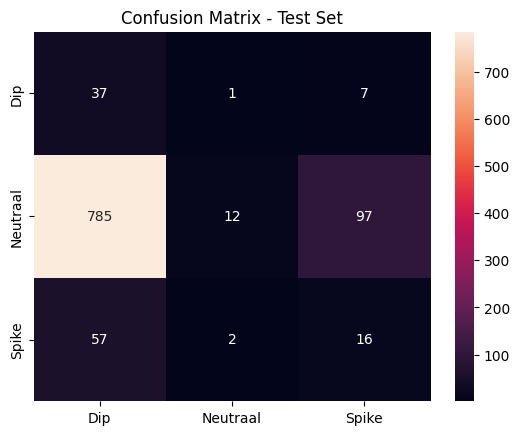

In [ ]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Set')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

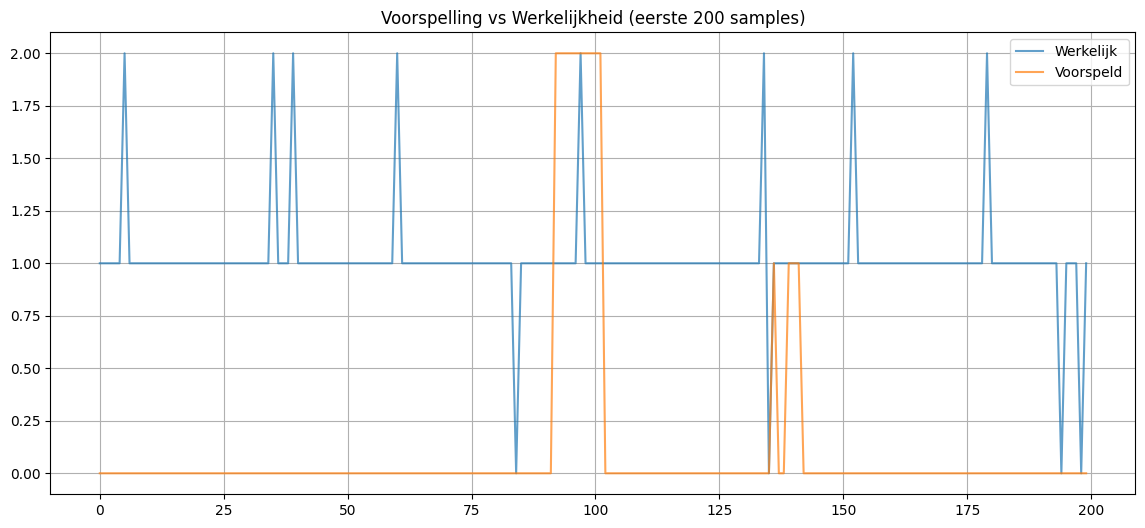

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Combineer resultaten
results_df = pd.DataFrame({
    "True": all_labels,
    "Pred": all_preds
})

# Map labels terug naar namen
label_map = {0: "Dip", 1: "Neutraal", 2: "Spike"}
results_df["TrueLabel"] = results_df["True"].map(label_map)
results_df["PredLabel"] = results_df["Pred"].map(label_map)

# Plot (eerste 200 punten voor leesbaarheid)
plt.figure(figsize=(14,6))

plt.plot(results_df["True"].values[:200], label="Werkelijk", alpha=0.7)
plt.plot(results_df["Pred"].values[:200], label="Voorspeld", alpha=0.7)

plt.title("Voorspelling vs Werkelijkheid (eerste 200 samples)")
plt.legend()
plt.grid()
plt.show()

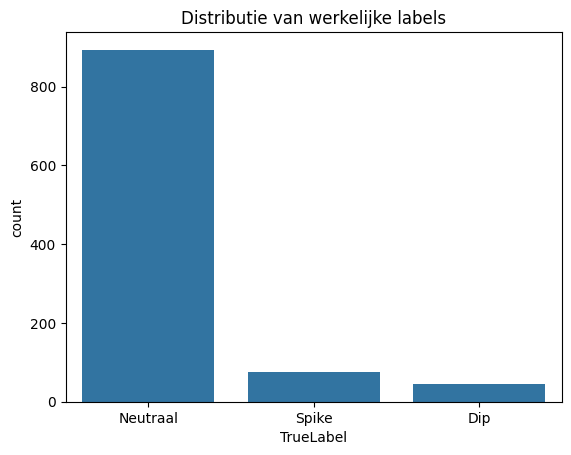

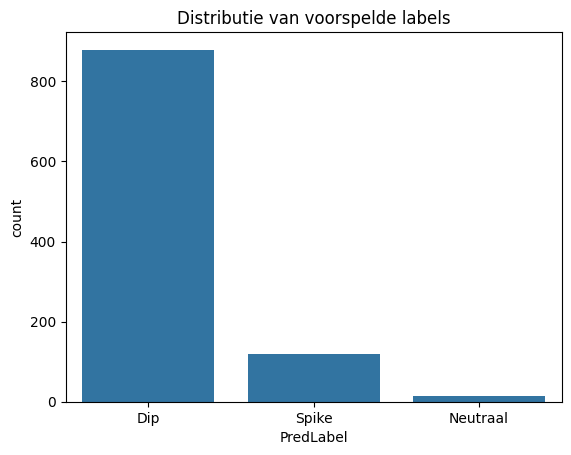

In [ ]:
import seaborn as sns

sns.countplot(x=results_df["TrueLabel"])
plt.title("Distributie van werkelijke labels")
plt.show()

sns.countplot(x=results_df["PredLabel"])
plt.title("Distributie van voorspelde labels")
plt.show()

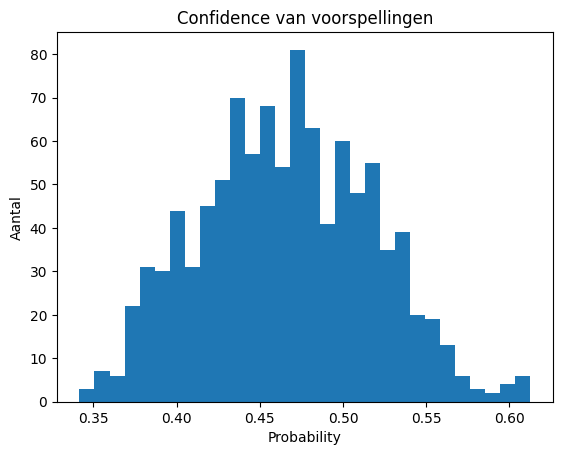

In [ ]:
import numpy as np

probs = np.array(all_probs)
confidence = probs.max(axis=1)

plt.hist(confidence, bins=30)
plt.title("Confidence van voorspellingen")
plt.xlabel("Probability")
plt.ylabel("Aantal")
plt.show()

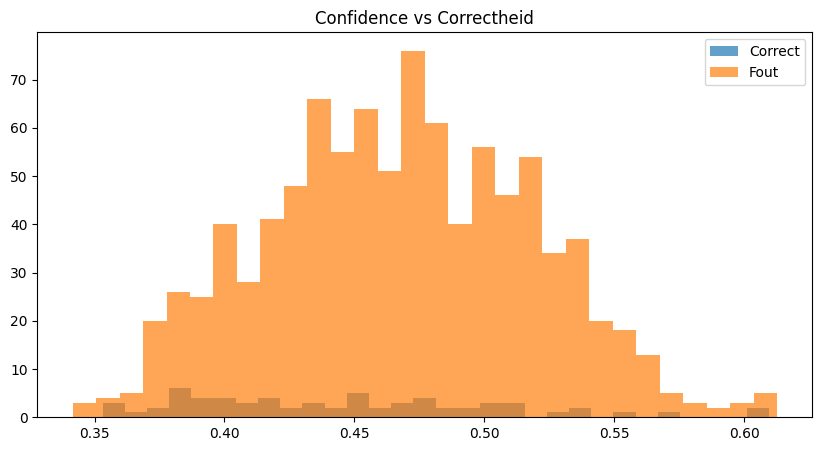

In [ ]:
correct = (results_df["True"] == results_df["Pred"])

plt.figure(figsize=(10,5))
plt.hist(confidence[correct], bins=30, alpha=0.7, label="Correct")
plt.hist(confidence[~correct], bins=30, alpha=0.7, label="Fout")

plt.legend()
plt.title("Confidence vs Correctheid")
plt.show()

In [ ]:
import numpy as np

def permutation_importance(model, dataloader, feature_cols):
    base_acc = 0
    total = 0

    model.eval()
    all_preds_base = []
    all_labels_base = []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(DEVICE)
            logits = model(X_batch)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds_base.extend(preds)
            all_labels_base.extend(y_batch.numpy())

    base_acc = (np.array(all_preds_base) == np.array(all_labels_base)).mean()

    importances = []

    for i, col in enumerate(feature_cols):
        all_preds_perm = []
        all_labels_perm = []

        with torch.no_grad():
            for X_batch, y_batch in dataloader:
                X_batch = X_batch.clone()
                
                # shuffle feature i
                idx = torch.randperm(X_batch.shape[0])
                X_batch[:,:,i] = X_batch[idx,:,i]

                X_batch = X_batch.to(DEVICE)
                logits = model(X_batch)
                preds = logits.argmax(dim=1).cpu().numpy()

                all_preds_perm.extend(preds)
                all_labels_perm.extend(y_batch.numpy())

        acc = (np.array(all_preds_perm) == np.array(all_labels_perm)).mean()
        importances.append(base_acc - acc)

    return pd.DataFrame({
        "feature": feature_cols,
        "importance": importances
    }).sort_values("importance", ascending=False)

fi_df = permutation_importance(model, test_loader, FEATURE_COLS)

In [ ]:
groups = {
    "Market": [
        'Return_1d','Return_5d','Return_10d','MA_cross_5_20','MA_cross_20_50',
        'Vol_5d','Vol_20d','RSI_14','BB_position','Volume_ratio','DayRange_pct'
    ],
    "Econ": [
        'USD','OIL','VIX','YieldSpread','InfExpectation','FinStress',
        'FedFundsRate','CPI','PPI','Consumer_Confidence'
    ],
    "News": [
        'AvgNewsSentiment','AvgNewsInfluence','NewsCount'
    ],
    "Twitter": [
        'AvgTweetSentiment','AvgTweetInfluence','TweetCount'
    ]
}

group_importance = {}

for group, feats in groups.items():
    group_importance[group] = fi_df[fi_df["feature"].isin(feats)]["importance"].sum()

group_df = pd.DataFrame(list(group_importance.items()), columns=["Group","Importance"])
group_df["Percentage"] = round(group_df["Importance"] / group_df["Importance"].sum() * 100,2)



In [ ]:
print(group_df)

     Group  Importance  Percentage
0   Market   -0.039448       53.33
1     Econ   -0.020710       28.00
2     News    0.002959       -4.00
3  Twitter   -0.016765       22.67


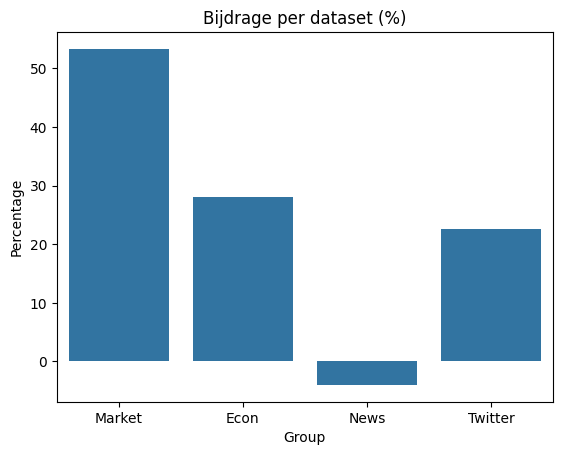

In [ ]:
sns.barplot(data=group_df, x="Group", y="Percentage")
plt.title("Bijdrage per dataset (%)")
plt.show()

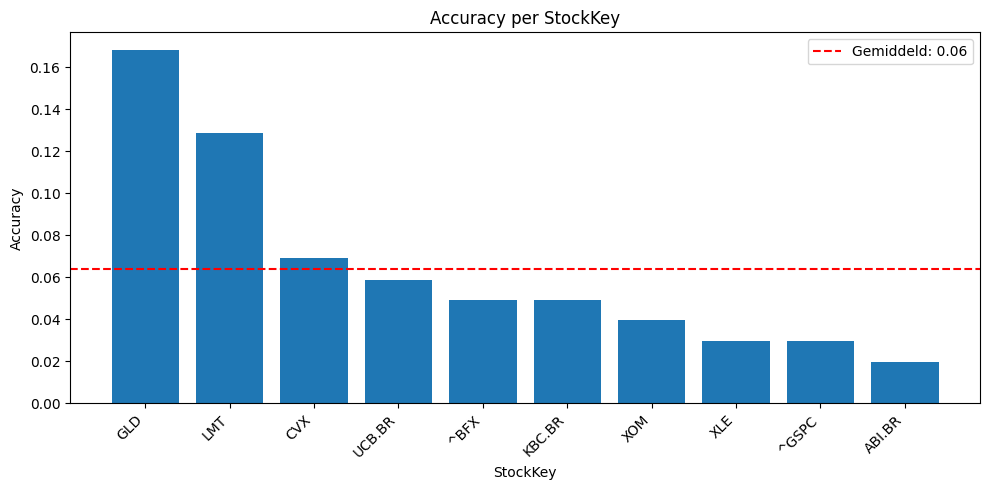

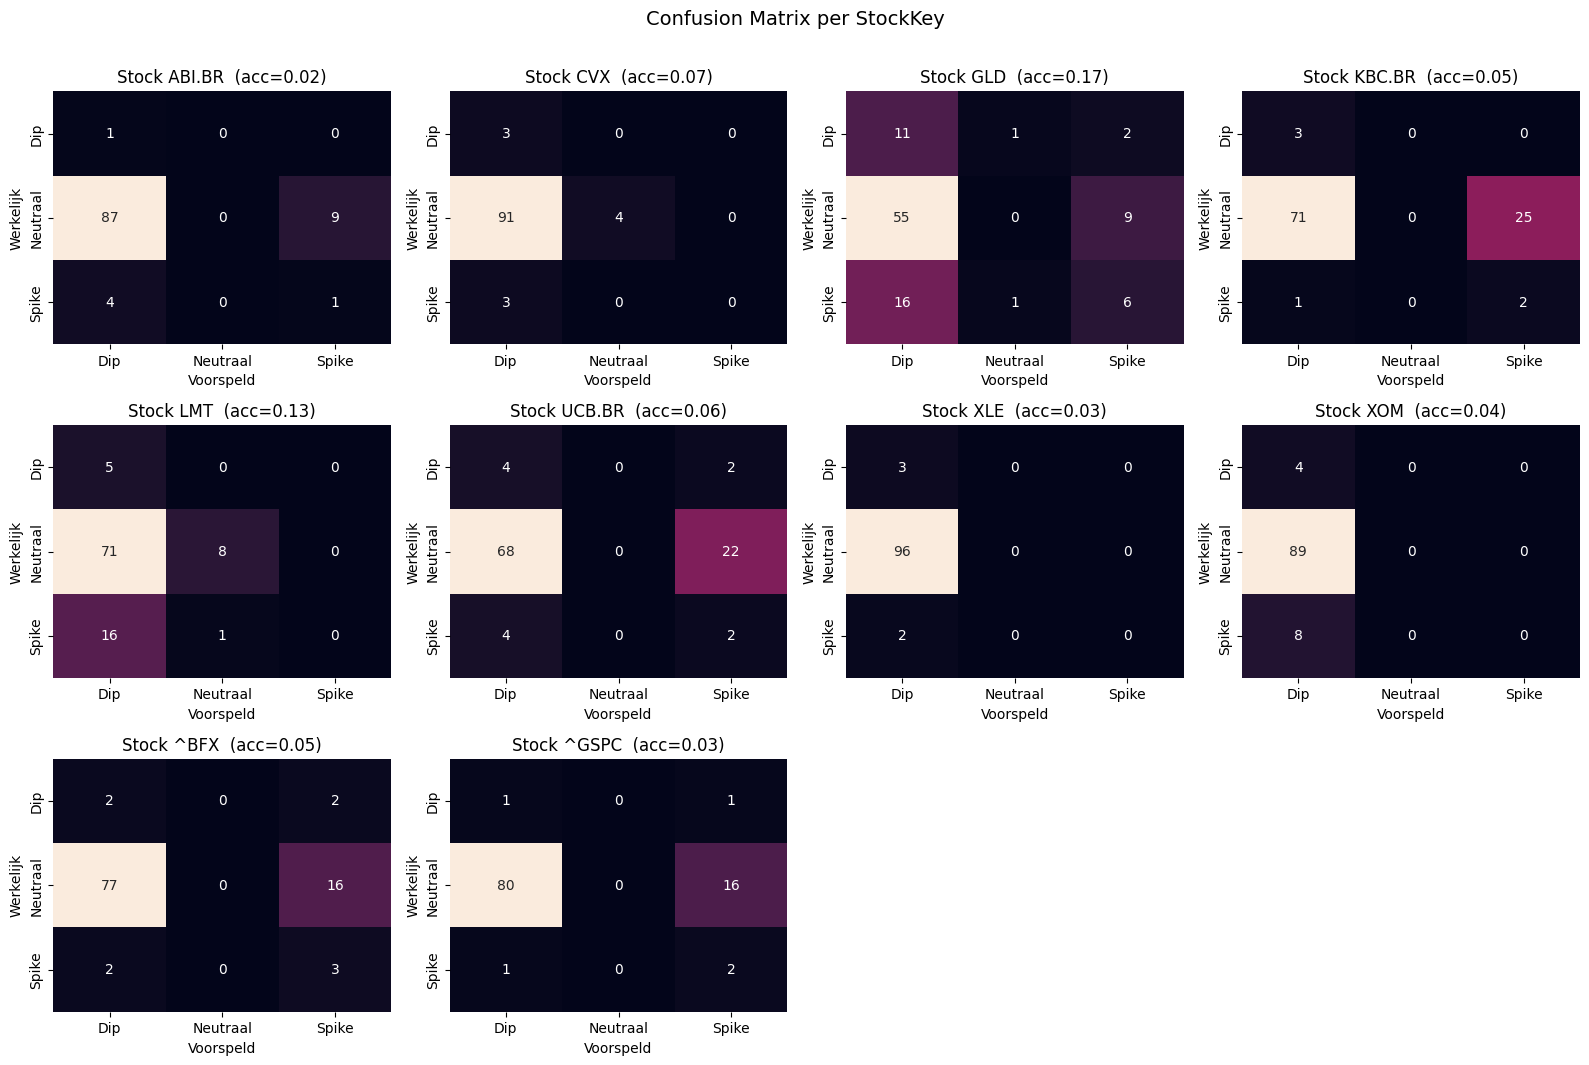

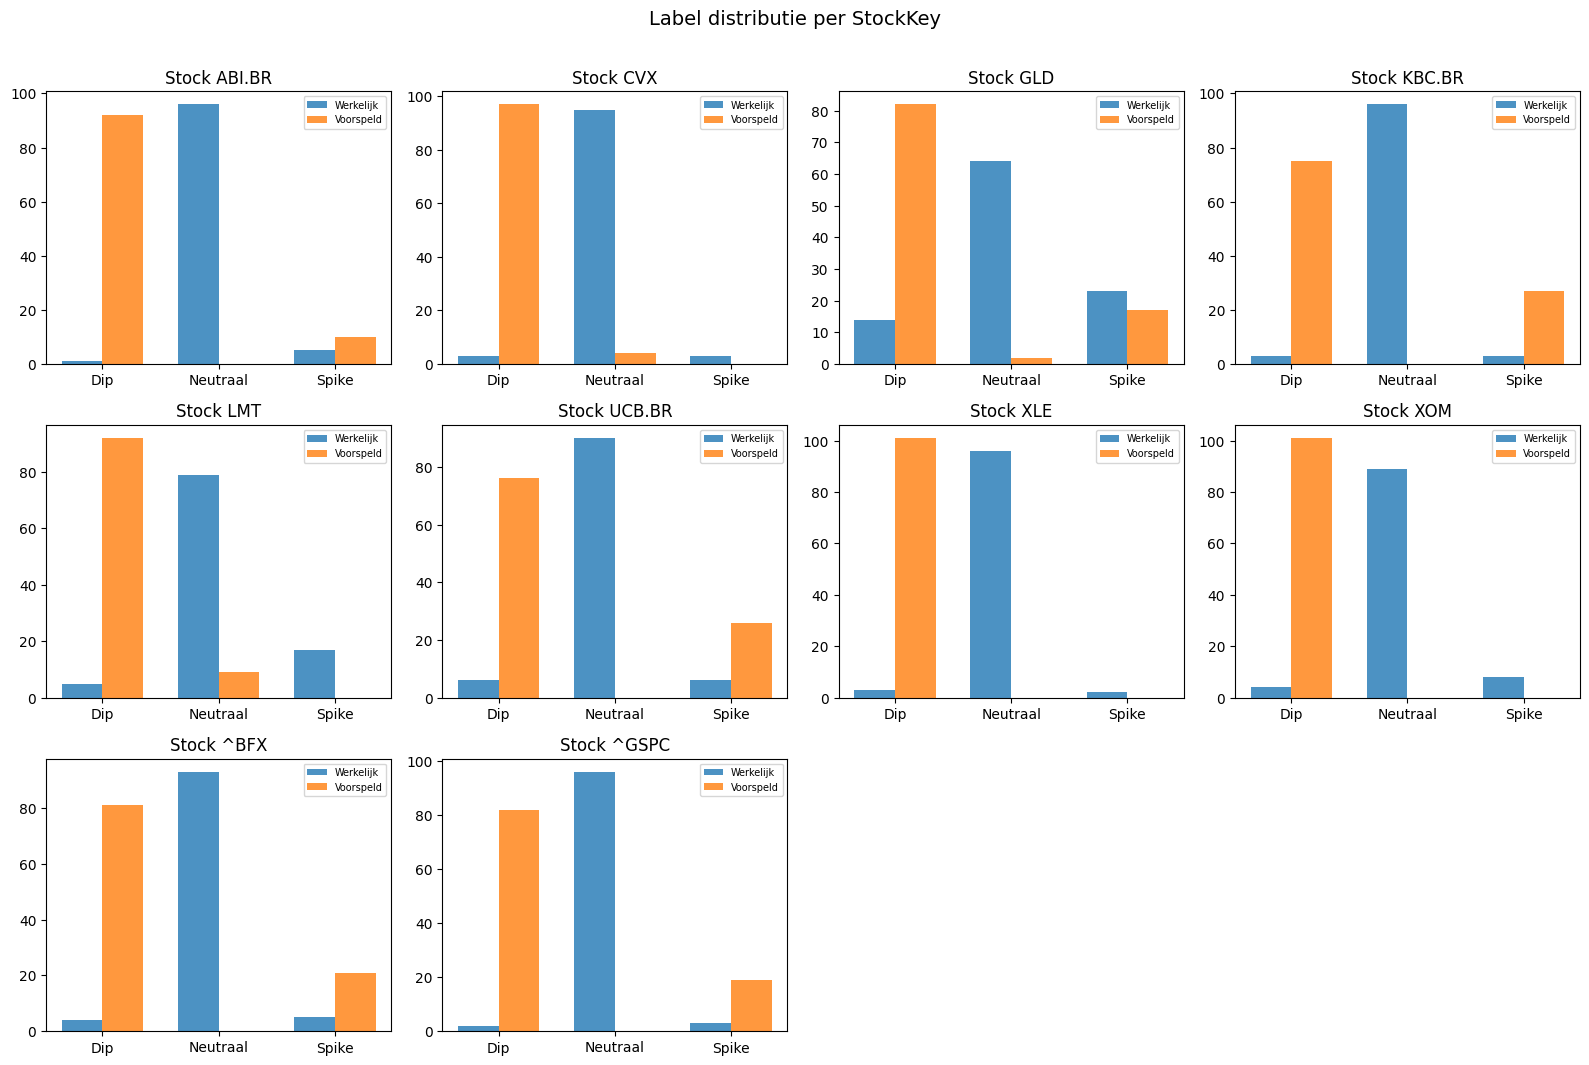

<Figure size 1000x500 with 0 Axes>

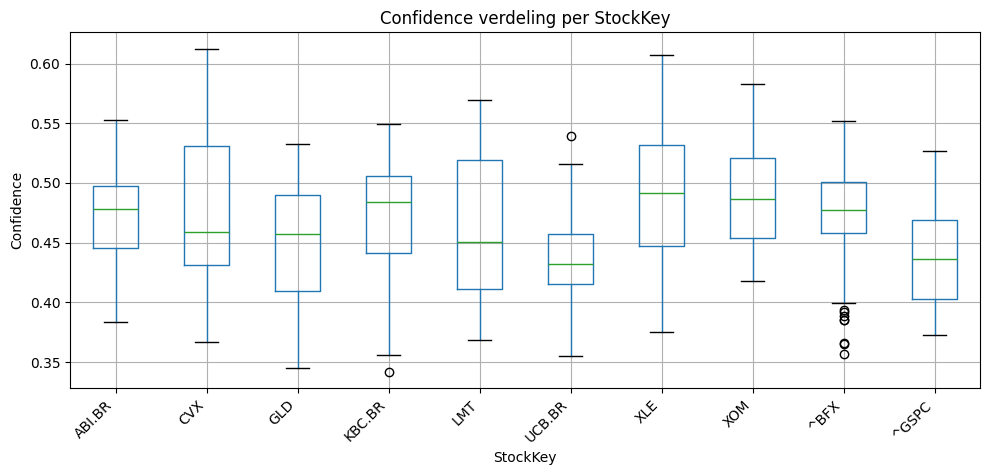

In [ ]:
# ─────────────────────────────────────────
# Voorspellingen per StockKey
# ─────────────────────────────────────────

# Rebuild test_ds met StockKey info
stock_keys = []
true_labels = []
pred_labels = []
prob_list = []

model.eval()
with torch.no_grad():
    for stock, grp in df_test.groupby('StockKey'):
        grp = grp.sort_values('TradeDate').reset_index(drop=True)
        X = grp[FEATURE_COLS].values.astype(np.float32)
        y = grp['Label'].values.astype(np.int64) + 1  # -1→0, 0→1, 1→2

        for i in range(SEQ_LEN, len(X)):
            x_tensor = torch.tensor(X[i - SEQ_LEN:i]).unsqueeze(0).to(DEVICE)
            logits = model(x_tensor)
            probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
            pred   = logits.argmax(dim=1).item()

            stock_keys.append(stock)
            true_labels.append(y[i])
            pred_labels.append(pred)
            prob_list.append(probs)

results_per_stock = pd.DataFrame({
    'StockKey':  stock_keys,
    'True':      true_labels,
    'Pred':      pred_labels,
    'Conf':      [p.max() for p in prob_list],
})

label_map = {0: 'Dip', 1: 'Neutraal', 2: 'Spike'}
results_per_stock['TrueLabel'] = results_per_stock['True'].map(label_map)
results_per_stock['PredLabel'] = results_per_stock['Pred'].map(label_map)
results_per_stock['Correct']   = results_per_stock['True'] == results_per_stock['Pred']

stocks = sorted(results_per_stock['StockKey'].unique())

# ── Grafiek 1: Accuracy per stock ──────────────────────────────────────────
acc_per_stock = (
    results_per_stock.groupby('StockKey')['Correct']
    .mean()
    .reset_index()
    .rename(columns={'Correct': 'Accuracy'})
    .sort_values('Accuracy', ascending=False)
)

plt.figure(figsize=(max(10, len(stocks) * 0.6), 5))
bars = plt.bar(acc_per_stock['StockKey'].astype(str), acc_per_stock['Accuracy'])
plt.axhline(acc_per_stock['Accuracy'].mean(), color='red',
            linestyle='--', label=f"Gemiddeld: {acc_per_stock['Accuracy'].mean():.2f}")
plt.title('Accuracy per StockKey')
plt.xlabel('StockKey')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('accuracy_per_stock.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Grafiek 2: Confusion matrix per stock (subplots) ──────────────────────
n_stocks = len(stocks)
ncols = min(4, n_stocks)
nrows = (n_stocks + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = np.array(axes).flatten()

for idx, stock in enumerate(stocks):
    sub = results_per_stock[results_per_stock['StockKey'] == stock]
    cm  = confusion_matrix(sub['True'], sub['Pred'], labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx],
                xticklabels=['Dip','Neutraal','Spike'],
                yticklabels=['Dip','Neutraal','Spike'],
                cbar=False)
    acc = sub['Correct'].mean()
    axes[idx].set_title(f'Stock {stock}  (acc={acc:.2f})')
    axes[idx].set_xlabel('Voorspeld')
    axes[idx].set_ylabel('Werkelijk')

# Verberg lege subplots
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrix per StockKey', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('confusion_per_stock.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Grafiek 3: Label distributie per stock (True vs Pred) ─────────────────
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = np.array(axes).flatten()

for idx, stock in enumerate(stocks):
    sub = results_per_stock[results_per_stock['StockKey'] == stock]

    counts_true = sub['TrueLabel'].value_counts().reindex(['Dip','Neutraal','Spike'], fill_value=0)
    counts_pred = sub['PredLabel'].value_counts().reindex(['Dip','Neutraal','Spike'], fill_value=0)

    x    = np.arange(3)
    w    = 0.35
    ax   = axes[idx]
    ax.bar(x - w/2, counts_true.values, w, label='Werkelijk', alpha=0.8)
    ax.bar(x + w/2, counts_pred.values, w, label='Voorspeld',  alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(['Dip','Neutraal','Spike'])
    ax.set_title(f'Stock {stock}')
    ax.legend(fontsize=7)

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Label distributie per StockKey', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('distributie_per_stock.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Grafiek 4: Confidence per stock (boxplot) ─────────────────────────────
plt.figure(figsize=(max(10, len(stocks) * 0.6), 5))
results_per_stock.boxplot(column='Conf', by='StockKey', figsize=(max(10, len(stocks) * 0.6), 5))
plt.suptitle('')
plt.title('Confidence verdeling per StockKey')
plt.xlabel('StockKey')
plt.ylabel('Confidence')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confidence_per_stock.png', dpi=150, bbox_inches='tight')
plt.show()